# **Scenario 2: NMF**

## **Name:** SaiSanjay R
## **Roll.No:** 24BAD102

In [1]:

import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:

ratings = pd.read_csv("ratings.csv")

print("Dataset Shape:", ratings.shape)
print("\nSample Data:\n", ratings.head())

Dataset Shape: (43084, 4)

Sample Data:
    userId  movieId  rating    timestamp
0       1        1     4.0  964982703.0
1       1        3     4.0  964981247.0
2       1        6     4.0  964982224.0
3       1       47     5.0  964983815.0
4       1       50     5.0  964982931.0


In [3]:
# Create User-Item Matrix

ratings = ratings[['userId', 'movieId', 'rating']]

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

print("\nUnique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())
print("\nUser-Item Matrix Shape:", user_item_matrix.shape)


Unique Users: 288
Unique Movies: 6433

User-Item Matrix Shape: (288, 6433)


In [4]:
# Handle Missing Values

matrix_filled = user_item_matrix.fillna(0)

sparsity = 1.0 - np.count_nonzero(matrix_filled.values) / matrix_filled.size
print("\nMatrix Sparsity:", round(sparsity, 4))


Matrix Sparsity: 0.9767


In [5]:
# Apply NMF Model

k_values = [10, 20, 50]

results = []

In [6]:
for k in k_values:
    print(f"\n===== Using k = {k} latent factors =====")

    nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)


    # Factorization

    W = nmf_model.fit_transform(matrix_filled)   # User-feature
    H = nmf_model.components_                    # Item-feature

    print("User-feature matrix (W) shape:", W.shape)
    print("Item-feature matrix (H) shape:", H.shape)


    # Reconstruction

    reconstructed = np.dot(W, H)

    pred_df = pd.DataFrame(reconstructed,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    # RMSE Calculation

    actual = user_item_matrix.values[user_item_matrix.notna()]
    predicted = pred_df.values[user_item_matrix.notna()]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("RMSE:", rmse)


    # Precision@K and Recall@K

    def precision_recall_at_k(user_id, k_recs=5, threshold=3.5):
        user_actual = user_item_matrix.loc[user_id]
        user_pred = pred_df.loc[user_id]

        relevant = user_actual[user_actual >= threshold].index
        recommended = user_pred.sort_values(ascending=False).head(k_recs).index

        true_positive = len(set(recommended) & set(relevant))

        precision = true_positive / k_recs
        recall = true_positive / len(relevant) if len(relevant) > 0 else 0

        return precision, recall

    precisions = []
    recalls = []

    for user in user_item_matrix.index[:50]:  # sample users
        p, r = precision_recall_at_k(user)
        precisions.append(p)
        recalls.append(r)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    print("Precision@5:", round(avg_precision, 4))
    print("Recall@5:", round(avg_recall, 4))

    results.append((k, rmse, avg_precision, avg_recall, pred_df))


===== Using k = 10 latent factors =====
User-feature matrix (W) shape: (288, 10)
Item-feature matrix (H) shape: (10, 6433)
RMSE: 2.623051378105685
Precision@5: 0.596
Recall@5: 0.0593

===== Using k = 20 latent factors =====
User-feature matrix (W) shape: (288, 20)
Item-feature matrix (H) shape: (20, 6433)
RMSE: 2.3994104483723593
Precision@5: 0.612
Recall@5: 0.0625

===== Using k = 50 latent factors =====
User-feature matrix (W) shape: (288, 50)
Item-feature matrix (H) shape: (50, 6433)
RMSE: 1.9458836025646014
Precision@5: 0.712
Recall@5: 0.0715


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [7]:

# Top-N Recommendations

def recommend_movies(user_id, pred_df, n=5):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return recs

best_model = results[-1][4]  # use highest k

print("\n===== Top Recommendations for User 1 =====")
print(recommend_movies(1, best_model, 5))


===== Top Recommendations for User 1 =====
movieId
2599    1.396194
1610    1.222135
1215    1.055455
1387    1.033183
1259    0.921234
Name: 1, dtype: float64


In [8]:

# Performance Table

print("\n===== Performance Table =====")
for k, rmse, p, r, _ in results:
    print(f"k = {k} | RMSE = {rmse:.4f} | Precision@5 = {p:.4f} | Recall@5 = {r:.4f}")


===== Performance Table =====
k = 10 | RMSE = 2.6231 | Precision@5 = 0.5960 | Recall@5 = 0.0593
k = 20 | RMSE = 2.3994 | Precision@5 = 0.6120 | Recall@5 = 0.0625
k = 50 | RMSE = 1.9459 | Precision@5 = 0.7120 | Recall@5 = 0.0715


In [9]:

# Predicted vs Actual

print("\n===== Predicted vs Actual Ratings (Sample) =====")

rows, cols = np.where(~np.isnan(user_item_matrix.values))

for i in range(10):
    r = rows[i]
    c = cols[i]

    actual_val = user_item_matrix.values[r, c]
    predicted_val = best_model.values[r, c]

    print(f"User {user_item_matrix.index[r]}, Movie {user_item_matrix.columns[c]} -> Actual: {actual_val}, Predicted: {predicted_val:.2f}")


===== Predicted vs Actual Ratings (Sample) =====
User 1, Movie 1 -> Actual: 4.0, Predicted: 3.90
User 1, Movie 3 -> Actual: 4.0, Predicted: 3.42
User 1, Movie 6 -> Actual: 4.0, Predicted: 4.32
User 1, Movie 47 -> Actual: 5.0, Predicted: 4.61
User 1, Movie 50 -> Actual: 5.0, Predicted: 5.33
User 1, Movie 70 -> Actual: 3.0, Predicted: 2.86
User 1, Movie 101 -> Actual: 5.0, Predicted: 4.59
User 1, Movie 110 -> Actual: 4.0, Predicted: 4.31
User 1, Movie 151 -> Actual: 5.0, Predicted: 4.56
User 1, Movie 157 -> Actual: 5.0, Predicted: 4.79


In [10]:

# Dimensionality Reduction Info
print("\nOriginal Matrix Size:", matrix_filled.shape)
print("Reduced Size (k=50):", results[-1][4].shape, "via W and H")


Original Matrix Size: (288, 6433)
Reduced Size (k=50): (288, 6433) via W and H


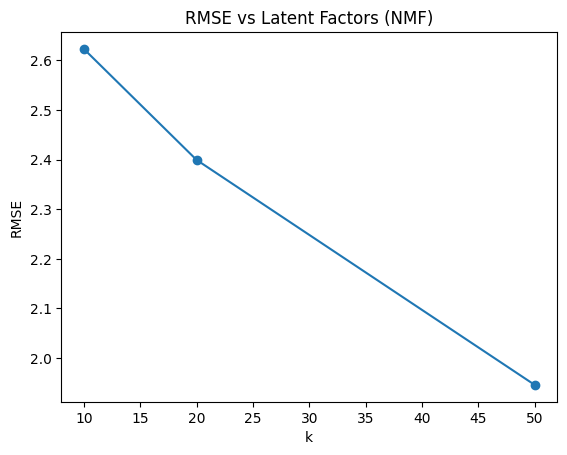

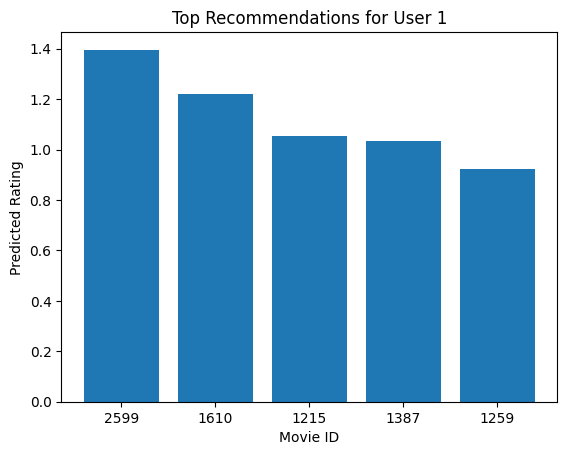

In [11]:

# Visualization


# RMSE vs k
k_list = [x[0] for x in results]
rmse_list = [x[1] for x in results]

plt.figure()
plt.plot(k_list, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (NMF)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

# Recommendation scores (User 1)
recs = recommend_movies(1, best_model, 5)

plt.figure()
plt.bar(range(len(recs)), recs.values)
plt.xticks(range(len(recs)), recs.index)
plt.title("Top Recommendations for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()